# ML4Phys 2023 Assignment 3
## Mayas Farhat

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F


from torchvision import transforms

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
%config InlineBackend.figure_format = 'retina'


device = "cuda" if torch.cuda.is_available() else "cpu"
print("GPU available: ", torch.cuda.is_available())


GPU available:  True


In [2]:
class MyDataset(Dataset):
 '''
When you define a method inside a class, the first parameter of that method is conventionally named self.
The self parameter refers to the instance of the class itself. It allows you to access and modify the instance's attributes (variables) and call other methods within the class.
 '''
class MyDataset(Dataset):
    def __init__(self, data, target, transform=None, target_transform=None):
        # constructor: initializes the dataset with the provided data, targets(labels), and transformations
        self.data = data  # input images
        self.target = target  # corresponding labels
        self.transform = transform  # transformation to be applied to the input data
        self.target_transform = target_transform  # transformation to be applied to the target labels.

    def __len__(self):
        return len(self.data)  # this method returns the total number of samples in the dataset

    def __getitem__(self, index):
        x = self.data[index]
        if self.transform:
            x = self.transform(x)

        y = self.target[index]
        if self.target_transform:
            y = self.target_transform(y)

        return x, y


## Question 1: Data loading and pre-processing

In [3]:
## download and read the .h5 data file
!wget http://www.astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5

--2023-12-19 17:54:08--  http://www.astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5
Resolving www.astro.utoronto.ca (www.astro.utoronto.ca)... 128.100.89.92
Connecting to www.astro.utoronto.ca (www.astro.utoronto.ca)|128.100.89.92|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5 [following]
--2023-12-19 17:54:09--  https://www.astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5
Connecting to www.astro.utoronto.ca (www.astro.utoronto.ca)|128.100.89.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 210234548 (200M)
Saving to: ‘Galaxy10.h5’

Galaxy10.h5         100%[===================>] 200.50M  45.0MB/s    in 4.9s    

2023-12-19 17:54:14 (40.9 MB/s) - ‘Galaxy10.h5’ saved [210234548/210234548]



In [4]:
# First create np.arrays from the data in the file, then make torch.Tensors from those.
# Directly going to torch.Tensor would be very slow in this case because h5py provides lazy access to the data, (see https://github.com/pytorch/pytorch/issues/13918).

# Read data and labels from the h5 file
# HDF5 file opened in read mode "r"
# code inside the with statement will execute with the file open, and once the block is exited, the file will be closed automatically.
with h5py.File("Galaxy10.h5", "r") as file:
    data = torch.from_numpy(np.array(file["images"])) # Converts the NumPy array into a PyTorch tensor
    labels = torch.from_numpy(np.array(file["ans"]))

# we change the data type and permute the color channel axis from place 3 to 1, to conform with pytorch defaults.
data = data.type(torch.float32).permute(0,3,1,2)  # (b, h, w, c) --> (b, c, h, w)
labels = labels.type(torch.LongTensor)

In [5]:
# Select a subset of the data to compute channel means and stds:
subset_indices = np.random.choice(len(data), size=1000, replace=False) #random subset/batch of 1000 indices in the range [0, len(data)). Sampling is done without replacement i.e. each index can only appear once in the subset
subset_data = data[subset_indices]
'''
subset_data = tensor representing a subset of the image data with dim (batch_size,
num_channels, height, width), where batch_size is the number of images in the subset, num_channels is the
number of color channels (e.g. Red, Green, and Blue), and height and width are the dimensions of each image.
'''

# Assuming data has dimensions (batch_size, channels, height, width)
batch_size, channels, height, width = subset_data.size()

# Step 1: Apply RandomCrop to the batch of images
crop_size = 48
random_crop = transforms.RandomCrop(size=crop_size)
cropped_data = torch.stack([random_crop(subset_data[i]) for i in range(batch_size)]) # random_crop applied to each image in subset_data batch --> stack along dim 0 : 4d tensor with dim (batch_size, channels, height, width)

# Step 2: Compute mean and std of the cropped batch for each channel
channel_means = cropped_data.mean(dim=(0, 2, 3))
channel_stds = cropped_data.std(dim=(0, 2, 3))

# Print mean and std for each channel
print("Channel Means:", channel_means)
print("Channel Stds:", channel_stds)

# Step 3: Define the "composed transform" with RandomCrop and Normalize
composed_transform = transforms.Compose([
    transforms.RandomCrop(size=crop_size),
    transforms.Normalize(mean=channel_means.tolist(), std=channel_stds.tolist())
])
'''
-Random cropping applied during the training phase to introduce variability into the training data by presenting the model with different views of the same image. Instead of always using the entire image,
random cropping allows the model to see different parts of it during each training iteration. A random position is chosen within the image. Then a sub-region, centered around the randomly selected position, is cropped.
- normalization by subtracting the mean and dividing by the standard deviation. The mean and std parameters are sequences of means and standard deviations for each color channel

- In PyTorch, the transforms.Compose object is not a function itself; it's an object that represents a sequence of transformations. However, you can use it as a callable if you want to apply the composed transformations to an input.
'composed_transform' is an instance of transforms.Compose, and it's used as a callable when applying it to each image in the dataset.
'''

# Verify normalization procedure
# Apply the composed transform to the cropped_data
normalized_data = torch.stack([composed_transform(cropped_data[i]) for i in range(batch_size)])

# Print mean and std of the normalized data
normalized_means = normalized_data.mean(dim=(0, 2, 3))
normalized_stds = normalized_data.std(dim=(0, 2, 3))

print("Normalized Means:", normalized_means)
print("Normalized Stds:", normalized_stds)


Channel Means: tensor([44.0965, 37.7129, 29.1515])
Channel Stds: tensor([45.8927, 38.4874, 32.4896])
Normalized Means: tensor([-6.1952e-07,  1.2674e-06,  1.0547e-07])
Normalized Stds: tensor([1.0000, 1.0000, 1.0000])


In [6]:
# Split data into 2 datasets
main_dataset_indices = labels < 8 # boolean mask to extract the subset of labels corresponding to the main dataset.
transfer_dataset_indices = (labels == 8) | (labels == 9)

main_data = data[main_dataset_indices]
main_labels = labels[main_dataset_indices]

transfer_data = data[transfer_dataset_indices]
transfer_labels = labels[transfer_dataset_indices] - 8  # Change labels to 0 & 1

In [7]:
# create train and test datasets for the two tasks (main and transfer-learning) as instances of the MyDataset class:

# Train-test split for the MAIN task : 18,000 training samples are selected randomly from the entire dataset main_data, and the remaining samples are used for testing.
main_train_data, main_test_data, main_train_labels, main_test_labels = train_test_split(
    main_data, main_labels, train_size=18000, test_size=main_data.shape[0] - 18000, random_state=42 )

# Train-test split for the TRANSFER task
transfer_train_data, transfer_test_data, transfer_train_labels, transfer_test_labels = train_test_split(
    transfer_data, transfer_labels, train_size=1000, test_size=transfer_data.shape[0] - 1000,
    random_state=42 )

# Create MyDataset OBJECTS
main_train_dataset = MyDataset(main_train_data, main_train_labels, transform=composed_transform)
main_test_dataset = MyDataset(main_test_data, main_test_labels, transform=composed_transform)

transfer_train_dataset = MyDataset(
    transfer_train_data, transfer_train_labels, transform=composed_transform )
transfer_test_dataset = MyDataset(
    transfer_test_data, transfer_test_labels, transform=composed_transform )

# Create data LOADERS with batch size 64
batch_size = 64

main_train_loader = DataLoader(main_train_dataset, batch_size=batch_size, shuffle=True) # specifies that the data should be loaded in batches
main_test_loader = DataLoader(main_test_dataset, batch_size=batch_size, shuffle=False)

transfer_train_loader = DataLoader(
    transfer_train_dataset, batch_size=batch_size, shuffle=True)
transfer_test_loader = DataLoader(
    transfer_test_dataset, batch_size=batch_size, shuffle=False)


## Question 2: Fully connected network

In [8]:
# Define the fully connected network
class FCN(nn.Module):   # FCN model inherits from nn.Module.
    def __init__(self, input_size, hidden_size, output_size):
        super(FCN, self).__init__() # super used to call a method from the parent/super class nn.Module
        self.model = nn.Sequential( # used to pass a sequence of modules (n.n. layers and activation functions, other operations) as arguments. Modules are then organized in a sequential manner i.e output of one module becomes the input to the next.
            nn.Flatten(),
            nn.Linear(input_size, hidden_size),  # fully connected (linear) layer with input_size input features and 64 output features (this is the only hidden layer)
            nn.ReLU(),        # activation function : sigma(x) = max(0, x) introduces non linearity
            nn.Linear(hidden_size, output_size)  # final output size is determined by the number of classes or categories the model is supposed to predict.
        )

    # forward method defined within the FCN class, to overrides the forward method of the superclass.
    def forward(self, x):
        return self.model(x) # pass the input tensor x through the sequential self.model. Output = predictions or activations produced by the n.n.
'''
'forward' method is automatically called when you pass input data through an instance of a class that inherits from nn.Module to process input data (performing forward computations).
'forward' specifies how the input data flows through the network to produce the output.
'''

# Function to TRAIN the MODEL (performs a SINGLE training epoch )
def train(model, train_loader, criterion, optimizer, device):
    model.train()  # Set model to training mode (Some layers, such as dropout layers, have different behavior during training and testing)
    running_train_loss = 0.0
    for batch, (X, y) in enumerate(train_loader):

        X, y = X.to(device), y.to(device) # moves the input & labels to the specified device (CPU or GPU)
        optimizer.zero_grad()  # Clear the grads from previous iterations (Grads accumulate by default, clear them before computing grads for current batch.)
        outputs = model(X)  # Forward pass through model generating predictions for the input
        loss = criterion(outputs, y)  # Computes loss  between model's pred (outputs) and the actual labels (labels) using the specified loss criterion.
        loss.backward()  # Backward pass to compute grads of the loss w.r.t model params (weights & biases). Grads represent the sensitivity of the loss to changes in each param -->used to update params in next line to minimize the loss.
        optimizer.step()  # Update model's weights using grads to adjust them in the direction that reduces the loss.
        running_train_loss += loss.item() # adds current batch's loss to a running total loss to keep track of the avg loss over an epoch.

    return running_train_loss / (batch + 1) #  normalising by total number of batches in the training data loader

''' criterion returns the PyTorch tensor 'loss' representing the computed loss value during the forward pass. Tensor also holds info about the computation graph that was used
to compute this loss. The comp graph is essential for backpropagation during the optimization process.
'.item()' extracts the numerical value current batch's loss value as a Python number '''

# Function to TEST the MODEL
def test(model, test_loader, criterion, device):
    model.eval() # Set the model to evaluation mode (some layers, such as dropout or batch normalization layers, may behave differently than during training.)
    running_test_loss = 0.0
    # disable gradient computation during testing to reduce memory usage and speed up computation (no backprop during testing)
    with torch.no_grad():
        for inputs, labels in test_loader: # Iterate over batches in the test loader
            inputs, labels = inputs.to(device), labels.to(device) # Move input & labels to specified device (CPU or GPU)
            outputs = model(inputs) # forward pass to get model predictions for the input data
            loss = criterion(outputs, labels) # loss between the predicted outputs and the actual labels
            running_test_loss += loss.item() # accumulate loss for current batch to the running total

    # Calculate and return the average loss per batch over the entire test dataset
    return running_test_loss / len(test_loader)

def evaluate_accuracy(model, data_loader, device):
    model.eval()  # Set the model to evaluation mode
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():  # Disable gradient computation during evaluation
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)  # Choose the class with the highest probability
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = correct_predictions / total_samples
    return accuracy

# Function to plot the training and testing losses
def plot_losses(train_losses, test_losses, model_name=""):
    plt.plot(train_losses, label=f'{model_name} Train Loss')
    plt.plot(test_losses, label=f'{model_name} Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Train and Test Losses vs. Epochs {model_name}')
    plt.show()


# Set random seed for reproducibility
torch.manual_seed(42)

# Initialize the model, criterion, and optimizer
# Assuming your input data has dimensions (batch_size, channels, height, width)
input_size = cropped_data.size(1) * cropped_data.size(2) * cropped_data.size(3) # input_size based on the size of the data used in the training loop.
hidden_size = 64
output_size = 8

fcn_model = FCN(input_size, hidden_size, output_size).to(device)# creates an instance/object of the FCN class and moves it to GPU
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(fcn_model.parameters(), lr=0.001) #fcn_model.parameters() tells the optimizer which weights & biases of the fcn_model should updated during training.
'''
optim.Adam() is a SGD variant that adapts learning rates (lrs) for each parameter.
Parameters that have larger grads will have their lr scaled down, preventing them from overshooting by taking excessively large steps during optimization.
Parameters that have smaller grads will have their lr scaled up, allowing them to take larger steps and converge faster (shorter training times).
The actual lr used for updating each parameter is the product of its individual lr and the global lr.
--> global lr=0.001 is a multiplier for all the individual lrs.
'''
# Train the model for 50 epochs
epochs = 50
fcn_train_losses = []
fcn_test_losses = []
fcn_accuracies = []

for epoch in range(epochs):
    train_loss = train(fcn_model, main_train_loader, criterion, optimizer, device)
    test_loss = test(fcn_model, main_test_loader, criterion, device)
    test_accuracy = evaluate_accuracy(fcn_model, main_test_loader, device)


    fcn_train_losses.append(train_loss)
    fcn_test_losses.append(test_loss)
    fcn_accuracies.append(test_accuracy)

    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}')




Epoch 1/50, Train Loss: 1.4263, Test Loss: 1.3345, Accuracy: 0.4182
Epoch 2/50, Train Loss: 1.2697, Test Loss: 1.2371, Accuracy: 0.4725
Epoch 3/50, Train Loss: 1.1792, Test Loss: 1.1838, Accuracy: 0.5284
Epoch 4/50, Train Loss: 1.1373, Test Loss: 1.1134, Accuracy: 0.5377
Epoch 5/50, Train Loss: 1.0836, Test Loss: 1.0885, Accuracy: 0.5309
Epoch 6/50, Train Loss: 1.0675, Test Loss: 1.0647, Accuracy: 0.5966
Epoch 7/50, Train Loss: 1.0441, Test Loss: 1.0526, Accuracy: 0.5771
Epoch 8/50, Train Loss: 1.0348, Test Loss: 1.0027, Accuracy: 0.5864
Epoch 9/50, Train Loss: 1.0188, Test Loss: 1.0118, Accuracy: 0.6093
Epoch 10/50, Train Loss: 1.0281, Test Loss: 1.0231, Accuracy: 0.6021
Epoch 11/50, Train Loss: 1.0067, Test Loss: 1.0075, Accuracy: 0.5936
Epoch 12/50, Train Loss: 0.9919, Test Loss: 0.9801, Accuracy: 0.6051
Epoch 13/50, Train Loss: 0.9852, Test Loss: 1.0058, Accuracy: 0.6085
Epoch 14/50, Train Loss: 0.9739, Test Loss: 1.0051, Accuracy: 0.6051
Epoch 15/50, Train Loss: 0.9760, Test Loss:

For the plot of train and test losses for the FCN model see question 3 below

## Question 3: Convolutional network

In [ ]:
# Define the CNN class
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # CNN Backbone
        self.cnn_backbone = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(8, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(1296, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Classifier Head
        self.classifier_head = nn.Linear(64, 8)

    def forward(self, x): # this is automatically done when an instane of the CNN class is called, passing input trough the network
        x = self.cnn_backbone(x)
        x = self.classifier_head(x)
        return x

# Move the model to the GPU if available
cnn_model = CNN().to(device)

# Initialize the optimizer and criterion
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.002)
cnn_criterion = nn.CrossEntropyLoss()


# Train the CNN for 50 epochs
cnn_train_losses = []
cnn_test_losses = []
cnn_test_accuracies = []

for epoch in range(50):
    cnn_train_loss = train(cnn_model, main_train_loader, cnn_criterion, cnn_optimizer, device)
    cnn_test_loss = test(cnn_model, main_test_loader, cnn_criterion, device)
    cnn_test_accuracy = evaluate_accuracy(cnn_model, main_test_loader, device)

    cnn_train_losses.append(cnn_train_loss)
    cnn_test_losses.append(cnn_test_loss)
    cnn_test_accuracies.append(cnn_test_accuracy)

    print(f'Epoch {epoch + 1}/50, Train Loss: {cnn_train_loss:.4f}, Test Loss: {cnn_test_loss:.4f}, Test Accuracy: {cnn_test_accuracy:.4f}')

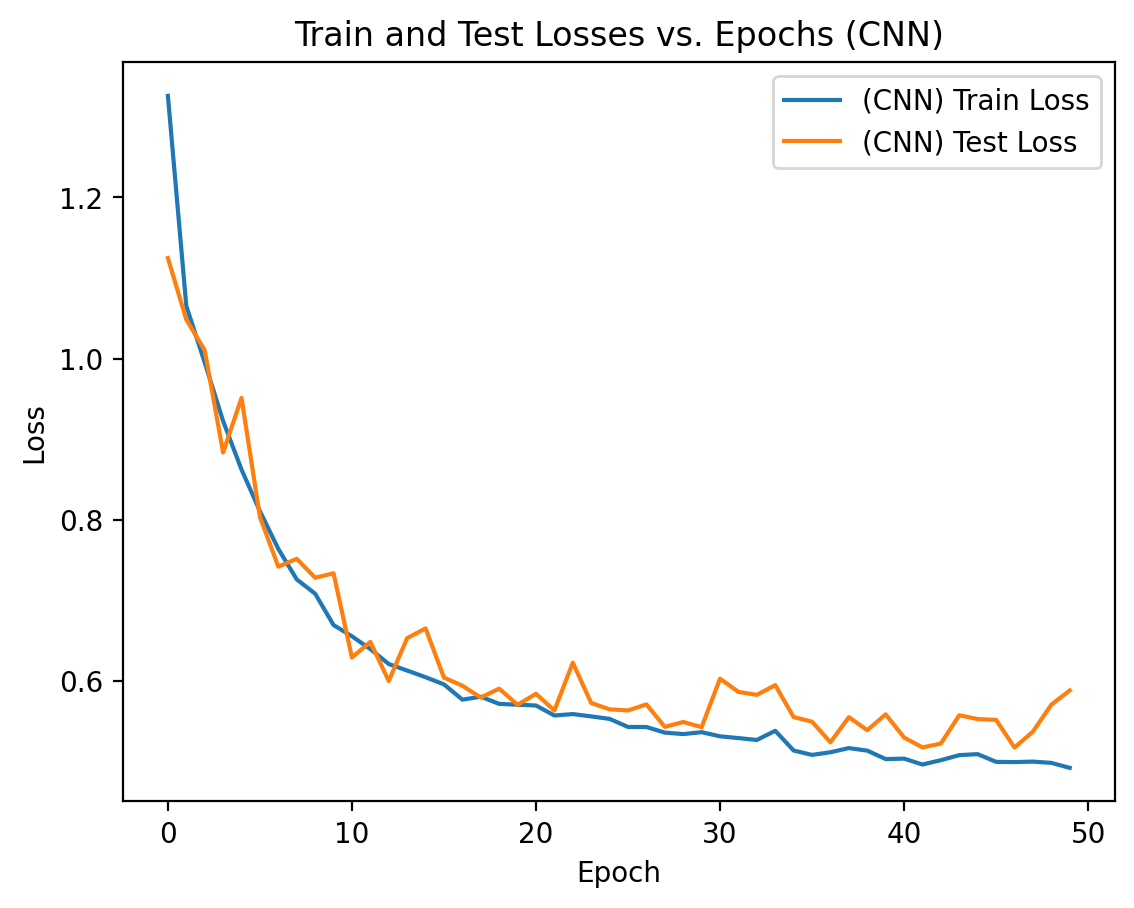

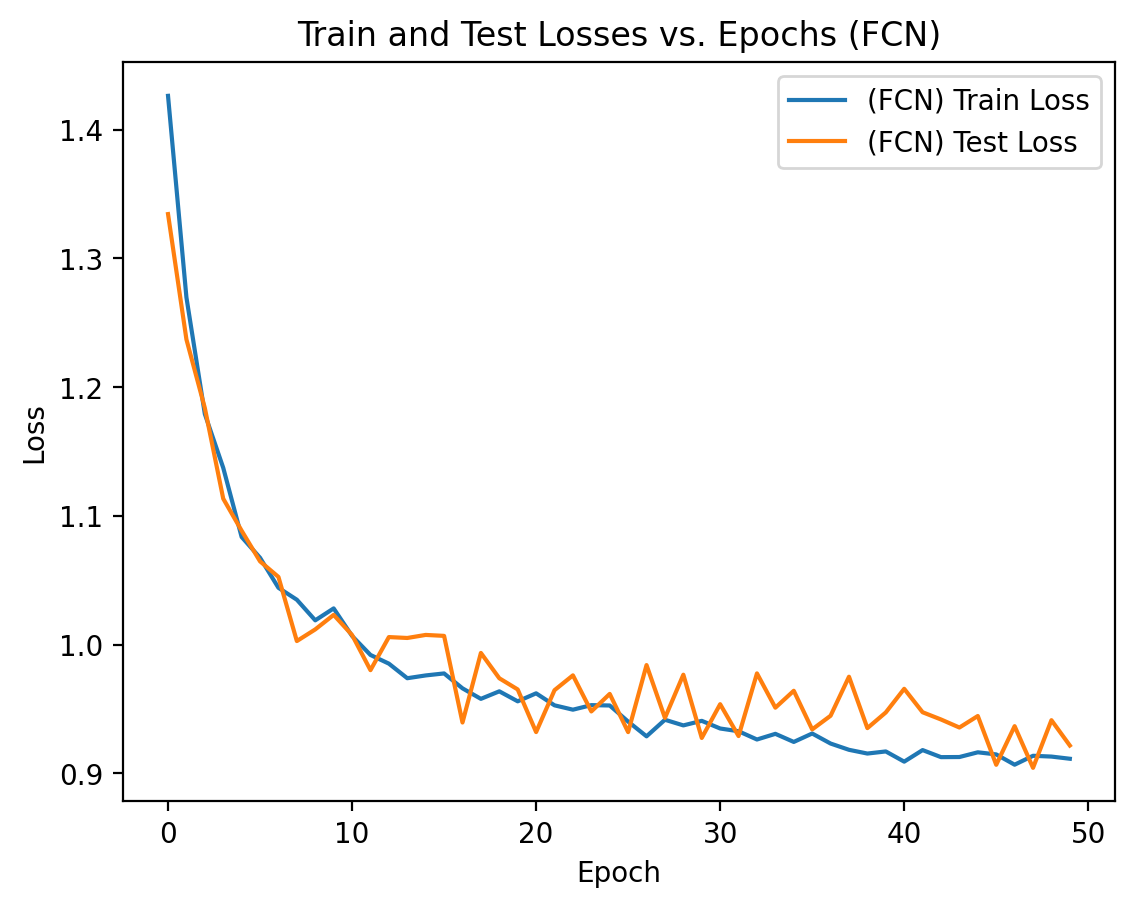

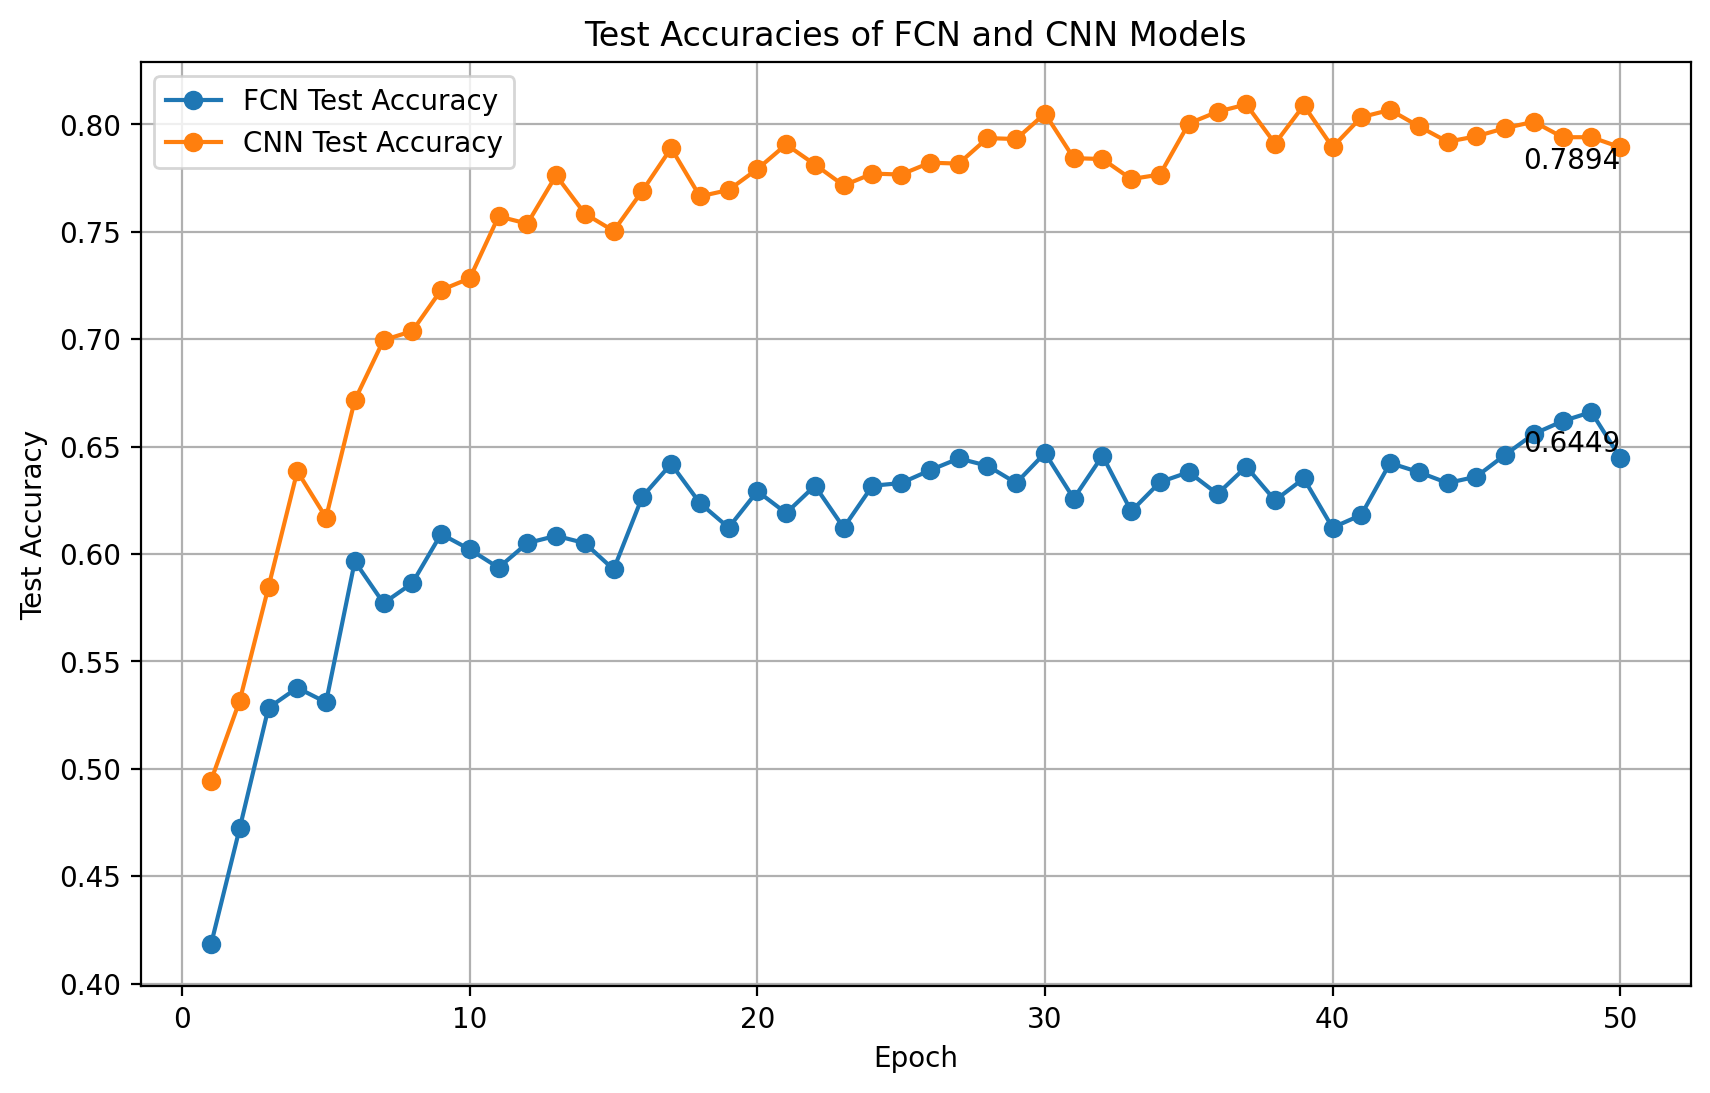

In [10]:
# Plot the losses and accuracies
plot_losses(cnn_train_losses, cnn_test_losses, "(CNN)")
plot_losses(fcn_train_losses, fcn_test_losses, "(FCN)")

def plot_accuracies(fcn_accuracies, cnn_accuracies, final_test_accuracies):
    epochs = range(1, len(fcn_accuracies) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, fcn_accuracies, label='FCN Test Accuracy', marker='o')
    plt.plot(epochs, cnn_accuracies, label='CNN Test Accuracy', marker='o')

    # Annotate final test accuracies
    plt.text(epochs[-1], fcn_accuracies[-1], f'{final_test_accuracies["fcn"]:.4f}', ha='right', va='bottom')
    plt.text(epochs[-1], cnn_accuracies[-1], f'{final_test_accuracies["cnn"]:.4f}', ha='right', va='top')

    plt.xlabel('Epoch')
    plt.ylabel('Test Accuracy')
    plt.title('Test Accuracies of FCN and CNN Models')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage:
final_test_accuracies = {"cnn": cnn_test_accuracies[-1], "fcn": fcn_accuracies[-1]}
plot_accuracies(fcn_accuracies, cnn_test_accuracies, final_test_accuracies)


We see the accuracy improves as the epoch increases, this can be understood considering in the following way:

Training a model involves updating its parameters (weights and biases) based on the error between predicted and actual values. With each epoch, the model has the opportunity to learn more about the relationships within the data and adjust its parameters accordingly.
The optimization algorithm used during training aims to find the optimal set of parameters that minimizes the loss function. This process may require multiple passes through the data to converge to the best parameter values.


We also notice a more stable decrease in the training loss contrary to the test loss which has a much stronger oscillation, even though it tends to decrease as the epoch number increases.


## Question 4: Confusion matrices

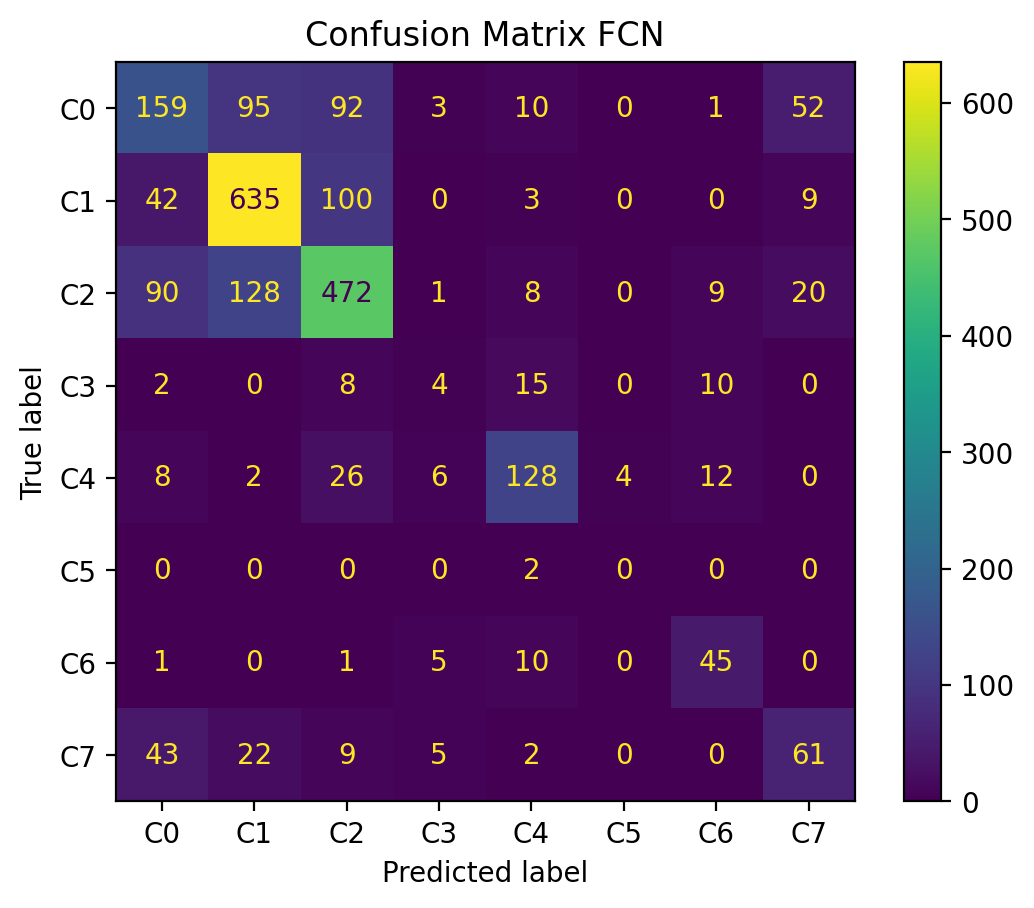

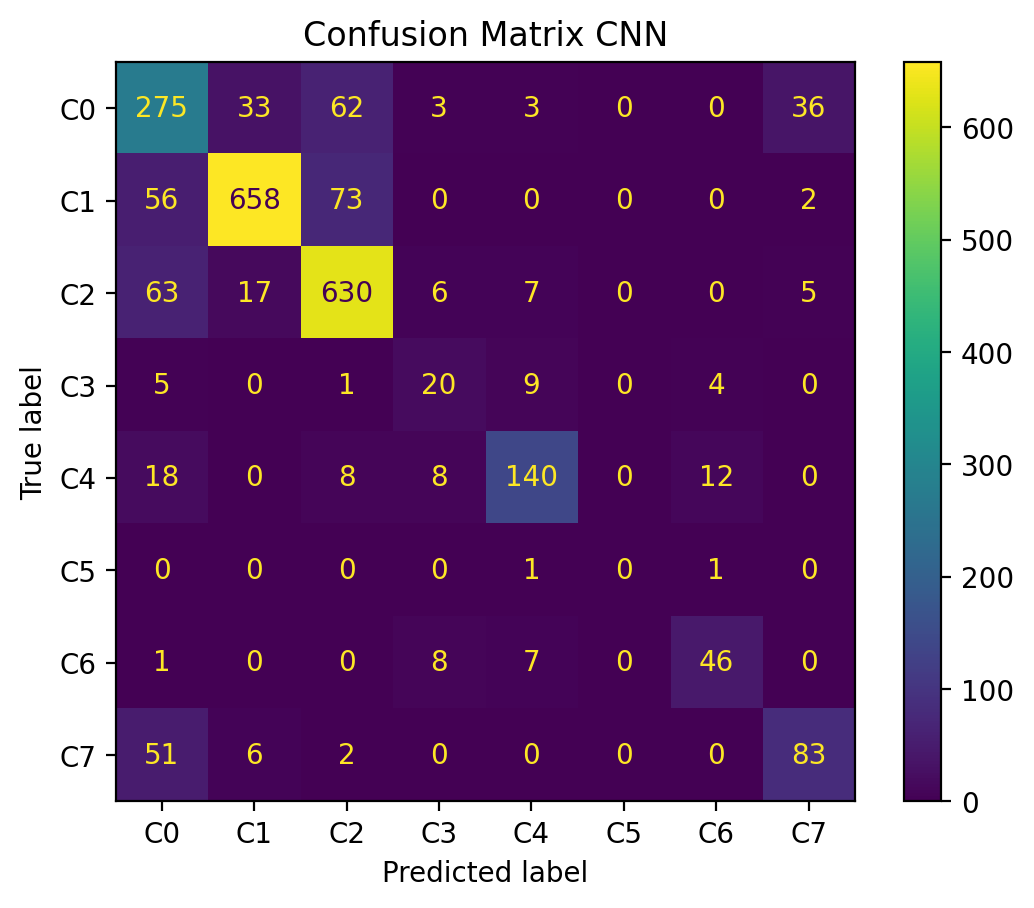

In [11]:

def compute_confusion_matrix(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader: #iterates over batches of data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)       # Passes the input data (inputs) through the model to get the model's predictions
            _, preds = torch.max(outputs, 1) # gets index of max value along a specified dimension (dim = 1, which represents the classes). 'preds' contains the predicted class labels for each input.
            #output of a neural network is a set of class scores or logits. Shape of outputs is typically (b, c).  A higher score for a particular class indicates that model is more confident that input belongs to that class. Choice of class = class with the highest score.
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels, confusion_matrix(all_labels, all_preds)
'''
While training, computations are often performed on a GPU for faster processing. However, when it comes to analyzing or visualizing the results, it's more convenient to work with data on the CPU. NumPy, a popular library for numerical computations in Python, works seamlessly with CPU data.
Moving tensors back to the CPU helps in releasing GPU memory. During training, GPU memory is used for storing model parameters, intermediate results, and batches of data. Once a batch is processed, moving the tensors to the CPU frees up GPU memory for the next batch.
'''


def plot_confusion_matrix(conf_matrix, classes, model_name=""):
    disp = ConfusionMatrixDisplay(conf_matrix, display_labels=classes)
    disp.plot(cmap='viridis', values_format='d')
    plt.title(f'Confusion Matrix {model_name}')
    plt.show()

# Assuming you have defined classes (replace it with your actual class names)
class_names = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']

# Compute and plot confusion matrix for FCN
fcn_all_preds, fcn_all_labels, fcn_conf_matrix = compute_confusion_matrix(fcn_model, main_test_loader, device)
plot_confusion_matrix(fcn_conf_matrix, class_names, 'FCN')

# Compute and plot confusion matrix for CNN
cnn_all_preds, cnn_all_labels, cnn_conf_matrix = compute_confusion_matrix(cnn_model, main_test_loader, device)
plot_confusion_matrix(cnn_conf_matrix, class_names, 'CNN')


In [13]:
# Assuming main_train_dataset is your training dataset for the FCN model
class_counts = {class_label: (main_train_dataset.target == class_label).sum().item() for class_label in range(8)}
                                         # the result of .sum() is a PyTorch tensor, and .item() extracts the Python scalar.

def calculate_accuracy_per_class(conf_matrix):
    # Calculate the diagonal elements (true positives) for each class
    true_positives = np.diag(conf_matrix)

    # Calculate the sum of each row in the confusion matrix (total actual instances for each class)
    total_actual = conf_matrix.sum(axis=1)

    # Avoid division by zero by handling cases where total_actual is zero
    accuracy_per_class = np.where(total_actual > 0, true_positives / total_actual, 0)

    return accuracy_per_class

# Calculate accuracy for each class for CNN and FCN
cnn_accuracy_per_class = calculate_accuracy_per_class(cnn_conf_matrix)
fcn_accuracy_per_class = calculate_accuracy_per_class(fcn_conf_matrix)

# Print the counts for each class
print('Number of training examples belonging to each class (main task) :\n --------------------------------------------' )
for class_label, count in class_counts.items():
   print(f'Class {class_label}: {count},    fcn accuracy : {fcn_accuracy_per_class[class_label]:.4f} ,    cnn accuracy : {cnn_accuracy_per_class[class_label]:.4f}')

Number of training examples belonging to each class (main task) :
 --------------------------------------------
Class 0: 3049,    fcn accuracy : 0.3859 ,    cnn accuracy : 0.6675
Class 1: 6208,    fcn accuracy : 0.8048 ,    cnn accuracy : 0.8340
Class 2: 5564,    fcn accuracy : 0.6484 ,    cnn accuracy : 0.8654
Class 3: 310,    fcn accuracy : 0.1026 ,    cnn accuracy : 0.5128
Class 4: 1348,    fcn accuracy : 0.6882 ,    cnn accuracy : 0.7527
Class 5: 15,    fcn accuracy : 0.0000 ,    cnn accuracy : 0.0000
Class 6: 527,    fcn accuracy : 0.7258 ,    cnn accuracy : 0.7419
Class 7: 979,    fcn accuracy : 0.4296 ,    cnn accuracy : 0.5845



Both models seem to have challenges with classes that have fewer samples (namely, cnn accuracy is 0,51 for Class 3 with only 310 training samples and no correct classifications for Class 5 with a mere 15 training samples).
Classes with similar visual features are more prone to be misclassified as each other.
To illustrate consider the two similar classes :
  - Class 0 : Disk, Face-on, No Spiral
  - Class 7 : Disk, Face-on, Tight Spiral \\

$\rightarrow$  CNN model falsely predicted 52 C7 type galaxies as C0. \\

Consider also :
  - Class 1 : Smooth, Completely round
  - Class 2 : Smooth, in-between round

$\rightarrow$ FCN model falsely predicted 109 C1 type galaxies as C2.

The unbalanced nature of the training dataset contributes to the challenges in classifying certain classes.
Further fine-tuning or increasing the number of samples for underrepresented classes can improve performance.

In [ ]:

def show_original_image(dataset, class_label):
    # Find indices of images with the specified class label
    indices = np.where(np.array(dataset.target) == class_label)[0]

    # Randomly choose one index
    random_index = np.random.choice(indices)

    # Get the image and label
    image, label = dataset[random_index]

    # Convert PyTorch tensor to NumPy array for visualization
    image_np = image.permute(1, 2, 0).numpy()

    # Display the image
    plt.imshow(image_np)
    plt.title(f'Class: {label}')
    plt.axis('off')
    plt.show()



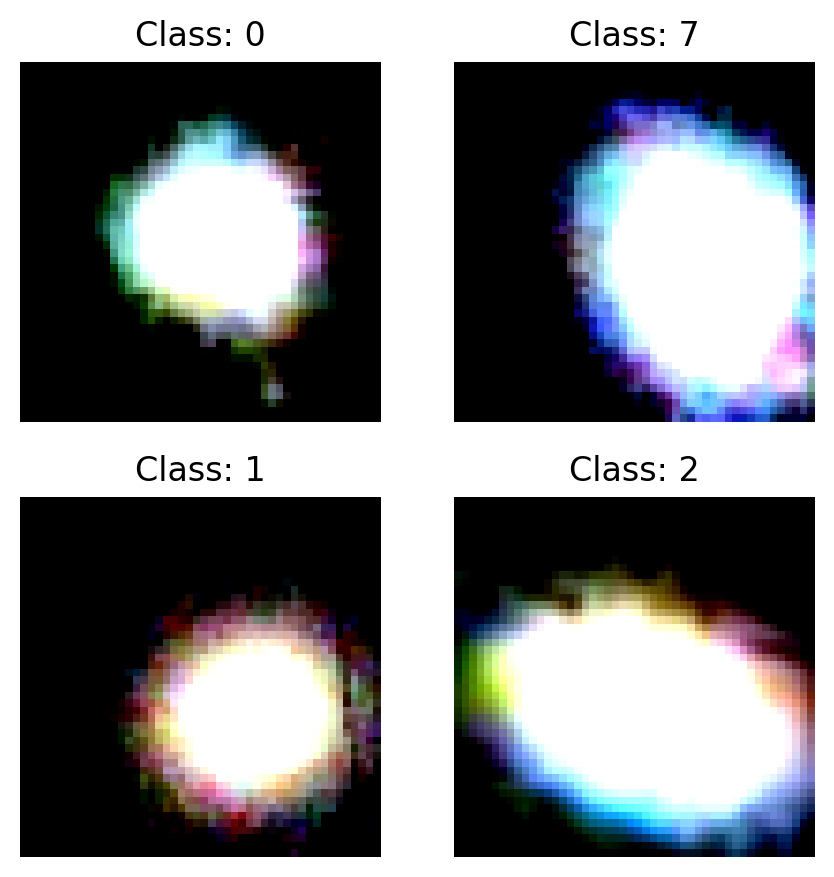

In [33]:
def show_original_images_subfigure(dataset, class_labels):
    num_rows, num_cols = 2, 2

    # Create a 2x2 subfigure
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(4.5, 4.5))

    # Loop through each class label
    for i in range(num_rows):
        for j in range(num_cols):
            class_label = class_labels[i * num_cols + j]

            # Find indices of images with the specified class label
            indices = np.where(np.array(dataset.target) == class_label)[0]

            # Randomly choose one index
            random_index = np.random.choice(indices)

            # Get the image and label
            image, label = dataset[random_index]

            # Convert PyTorch tensor to NumPy array for visualization
            image_np = image.permute(1, 2, 0).numpy()

            # Display the image in the subfigure
            axs[i, j].imshow(image_np)
            axs[i, j].set_title(f'Class: {label}')
            axs[i, j].axis('off')

    plt.tight_layout()
    plt.show()

# Example: Show subfigure with images from classes 0, 7, 1, and 2
show_original_images_subfigure(main_train_dataset, class_labels=[0, 7, 1, 2])


We see in the images amove why these classes are prone to be misclassified as eachother

## Question 5: Transfer learning

In [18]:
# Assume that cnn_backbone is the trained cnn backbone from the previous training
# and `device` is the device you're using (e.g., 'cuda' or 'cpu')
cnn_backbone = cnn_model.cnn_backbone

# Define a new classifier head for the new task
new_classifier_head = nn.Linear(64, 2) # randomly initialized linear layer going from 64 to 2 output features.

# Combine the trained cnn backbone and the new classifier head
fine_tuned_model = nn.Sequential(cnn_backbone, new_classifier_head)

# Move the model to the device (GPU)
fine_tuned_model = fine_tuned_model.to(device)

# Define the optimizer for the new classifier head
fine_tuned_optimizer = optim.Adam(new_classifier_head.parameters(), lr=0.005)#Give only the parameters of the final linear layer to the optimizer

# Define the loss criterion
fine_tuned_criterion = nn.CrossEntropyLoss()

# Freeze the weights of the cnn backbone
for param in cnn_backbone.parameters():
    param.requires_grad = False # tells PyTorch not to compute gradients for these parameters during backpropagation, i.e. they will not be updated during optimization step
                                # wights of pre-trained model are frozen while while fine-tuning only the weights of the newly added classifier head.
# Train for 20 epochs
fine_tuned_train_losses = []
fine_tuned_test_losses = []
fine_tuned_test_accuracies = []

for epoch in range(20):
    fine_tuned_train_loss = train(fine_tuned_model, transfer_train_loader, fine_tuned_criterion, fine_tuned_optimizer, device)
    fine_tuned_test_loss = test(fine_tuned_model, transfer_test_loader, fine_tuned_criterion, device)
    fine_tuned_test_accuracy = evaluate_accuracy(fine_tuned_model, transfer_test_loader, device)

    fine_tuned_train_losses.append(fine_tuned_train_loss)
    fine_tuned_test_losses.append(fine_tuned_test_loss)
    fine_tuned_test_accuracies.append(fine_tuned_test_accuracy)

    print(f'Epoch {epoch + 1}/20, Train Loss: {fine_tuned_train_loss:.4f}, Test Loss: {fine_tuned_test_loss:.4f}, Test Accuracy: {fine_tuned_test_accuracy:.4f}')

# Compute the final test accuracy
final_test_accuracy = fine_tuned_test_accuracies[-1]
print(f'Final Test Accuracy: {final_test_accuracy:.4f}')


Epoch 1/20, Train Loss: 0.5752, Test Loss: 0.4899, Test Accuracy: 0.8024
Epoch 2/20, Train Loss: 0.4895, Test Loss: 0.4490, Test Accuracy: 0.7882
Epoch 3/20, Train Loss: 0.4877, Test Loss: 0.4041, Test Accuracy: 0.8047
Epoch 4/20, Train Loss: 0.4728, Test Loss: 0.4359, Test Accuracy: 0.7882
Epoch 5/20, Train Loss: 0.4846, Test Loss: 0.4679, Test Accuracy: 0.7882
Epoch 6/20, Train Loss: 0.4439, Test Loss: 0.4585, Test Accuracy: 0.8118
Epoch 7/20, Train Loss: 0.4713, Test Loss: 0.4369, Test Accuracy: 0.8306
Epoch 8/20, Train Loss: 0.4473, Test Loss: 0.4625, Test Accuracy: 0.8024
Epoch 9/20, Train Loss: 0.4477, Test Loss: 0.4330, Test Accuracy: 0.8000
Epoch 10/20, Train Loss: 0.4686, Test Loss: 0.4370, Test Accuracy: 0.8000
Epoch 11/20, Train Loss: 0.4615, Test Loss: 0.4326, Test Accuracy: 0.8188
Epoch 12/20, Train Loss: 0.4610, Test Loss: 0.4489, Test Accuracy: 0.7882
Epoch 13/20, Train Loss: 0.4598, Test Loss: 0.4424, Test Accuracy: 0.7976
Epoch 14/20, Train Loss: 0.4700, Test Loss: 0.4